# Sprint IA & ML — Predição de risco de evasão de clientes (Ford VIN Share)

**Desafio Ford/FIAP nº 2** — reduzir a evasão silenciosa de clientes da rede oficial
de pós-venda. Este notebook é o entregável de IA/ML da sprint, construído sobre o
projeto real [`ford-next`](https://github.com/0ldev/ford-next) (dashboard + API +
motor de leads já em produção) e sobre a base real fornecida pela Ford
(**602.788 ordens de serviço, 175.554 veículos únicos, 435 concessionárias, 20
modelos**, 2020–2026).

## Documentação resumida da solução

O projeto já opera um pipeline de produção que rotula cada veículo como `em_risco`
a partir de uma regra de negócio (gap entre o intervalo de manutenção esperado do
modelo e o tempo real desde o último serviço) e treina um classificador para apoiar
a priorização de leads. Este notebook:

1. Analisa o problema e os dados disponíveis (Seção 1);
2. Trata valores ausentes, outliers e cria variáveis novas (Seção 2) — inclui a
   **descoberta de vazamento de dados (data leakage)** na feature de produção e a
   construção de um segundo conjunto de features "genuíno" para um desafio preditivo
   real;
3. Treina e compara Regressão Logística, Árvore de Decisão e Random Forest, com
   ajuste de hiperparâmetros (Seção 3);
4. Avalia e compara os modelos com métricas adequadas ao problema (Seção 4);
5. Conclui com o modelo selecionado, discussão de deploy e trabalhos futuros —
   incluindo uma comparação qualitativa com o modelo **Jev** (Seção 5).

Todos os números deste notebook são gerados a partir da execução real do pipeline
existente (`src/interfaces/pipeline/`) sobre o dataset real — nada aqui é sintético
ou estimado à mão.

## 1. Compreensão do problema (1,5 ponto)

**Problema de negócio.** A Ford perde receita de pós-venda quando um cliente para
de levar o veículo a uma concessionária oficial sem cancelar/vender o veículo —
"evasão silenciosa": não há um evento explícito de churn para rotular, só o
sintoma (o veículo para de aparecer no histórico de serviços).

**Objetivo da solução.** Prever, por veículo (VIN), um **score de risco de
evasão** que alimenta a priorização de leads e o motor de ações (lembrete, oferta
ou contato ativo) já existentes no projeto — o objetivo de ML é justamente essa
etapa 2 do fluxo (Geração de Leads e Modelagem Preditiva).

**Caracterização do problema.** É um problema de **classificação binária
supervisionada**: `em_risco ∈ {False, True}` por VIN. Poderia também ser
modelado como regressão (prever o `gap_relativo` contínuo em vez do rótulo
binário), mas a decisão de produto já fixou um corte de decisão (ver Seção 2),
então classificação é a formulação usada aqui.

In [1]:
import os
import sys
import pathlib
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path("..").resolve()))
os.chdir(pathlib.Path("..").resolve())  # backend/ — caminhos do pipeline (data/raw/...) são relativos a ele

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.interfaces.pipeline.build_service_history import build_service_history
from src.interfaces.pipeline.build_features import build_features_table
from src.application.build_vehicle_features import (
    compute_service_count_and_gap_std,
    compute_distinct_dealers_count,
    compute_dentro_garantia,
)
from src.domain.km_cleaning import winsorize_km
from src.domain.risk_label import GAP_RELATIVO_THRESHOLD
from src.application.train_risk_model import (
    temporal_train_test_split,
    train_logistic_regression,
    train_decision_tree,
    evaluate_auc,
    evaluate_precision_at_k,
    FEATURE_COLUMNS as FEATURE_COLUMNS_PRODUCAO,
)

# Paleta categórica validada (skill de dataviz) — ordem fixa, nunca ciclada.
COR_1_AZUL = "#2a78d6"
COR_2_LARANJA = "#eb6834"
COR_3_AQUA = "#1baf7a"
COR_4_AMARELO = "#eda100"
COR_TEXTO_SECUNDARIO = "#52514e"

REFERENCE_DATE = pd.Timestamp.now().normalize()

df_hist = build_service_history()
features_prod = build_features_table(reference_date=REFERENCE_DATE)

print(f"Histórico de serviços (normalizado/deduplicado): {len(df_hist):,} ordens")
print(f"Tabela de features por veículo: {features_prod.shape[0]:,} VINs, {features_prod.shape[1]} colunas")
features_prod.head()

Histórico de serviços (normalizado/deduplicado): 535,821 ordens
Tabela de features por veículo: 175,554 VINs, 11 colunas


,VIN_Hash,dias_desde_ultimo_servico,ModelName,intervalo_mediano_esperado,gap_relativo,n_servicos,idade_dias,ultimo_servico,DealerCode,gap_com_fallback,em_risco
0,00008eef200a0a71fd52b4b0bd43c6e275b50a8fe56a6f...,1669,KA,250.0,6.676000,1,2074,2022-03-03,3050,8.296000,True
1,0000a048f5503e31fd931282b6f932507b5a7e02bf4de6...,312,RANGER,144.0,2.166667,1,558,2025-11-19,6124,3.875000,True
2,00015a2ad3fd2a788fb2ccf83b443e5326b3d835b53468...,2141,RANGER,144.0,14.868056,1,2421,2020-11-16,2606,16.812500,True
3,00028f8619d418ce4614ca8637d870db50eeb42f22562f...,202,RANGER,144.0,1.402778,1,528,2026-03-09,5305,3.666667,True
4,0002a2d7b0e64c34a5cd3fdc69c387d28128474230d897...,1102,KA,250.0,4.408000,3,2148,2023-09-21,5650,4.408000,True


**Variáveis disponíveis** (tabela de produção, uma linha por VIN): `idade_dias`
(idade do veículo), `n_servicos` (nº de serviços realizados), `gap_relativo` e
`gap_com_fallback` (razão entre tempo sem serviço e intervalo esperado do modelo —
é a variável que define o rótulo), `ultimo_servico`/`DealerCode` (metadados),
`ModelName` (modelo do veículo) e o rótulo `em_risco`. Vêm também do histórico de
serviços bruto: `KM`, `WarrantyStartDate`, `DealerCode` por serviço, `ModelYear`.

In [2]:
print(features_prod.dtypes)
print("\nValores ausentes por coluna (%):")
print((features_prod.isna().mean() * 100).round(2))
print("\nDistribuição do rótulo em_risco:")
display_counts = features_prod["em_risco"].value_counts(normalize=True).rename("proporcao")
print(display_counts)

VIN_Hash                                 str
dias_desde_ultimo_servico              int64
ModelName                                str
intervalo_mediano_esperado           float64
gap_relativo                         float64
n_servicos                             int64
idade_dias                             int64
ultimo_servico                datetime64[us]
DealerCode                             int64
gap_com_fallback                     float64
em_risco                             boolean
dtype: object

Valores ausentes por coluna (%):
VIN_Hash                      0.0
dias_desde_ultimo_servico     0.0
ModelName                     0.0
intervalo_mediano_esperado    0.0
gap_relativo                  0.0
n_servicos                    0.0
idade_dias                    0.0
ultimo_servico                0.0
DealerCode                    0.0
gap_com_fallback              0.0
em_risco                      0.0
dtype: float64

Distribuição do rótulo em_risco:
em_risco
True     0.744648
False  

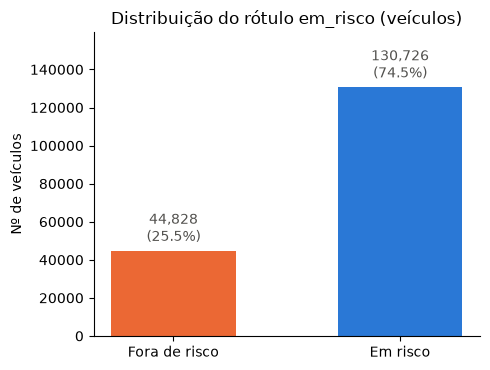

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.8))
contagem = features_prod["em_risco"].value_counts().sort_index()
cores = [COR_2_LARANJA, COR_1_AZUL]
barras = ax.bar(["Fora de risco", "Em risco"], contagem.values, color=cores, width=0.55)
ax.set_ylim(0, contagem.max() * 1.22)
for barra, valor in zip(barras, contagem.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + contagem.max() * 0.02,
            f"{valor:,}\n({valor / len(features_prod):.1%})",
            ha="center", va="bottom", fontsize=10, color=COR_TEXTO_SECUNDARIO)
ax.set_title("Distribuição do rótulo em_risco (veículos)")
ax.set_ylabel("Nº de veículos")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

O rótulo é desbalanceado (~74% "em risco"), consequência direta do threshold de
negócio (`gap_relativo > 2.0`, ver `src/domain/risk_label.py`) — decisão já
validada pelo time em issue anterior por plausibilidade de distribuição, não por
métrica de ML (AUC satura perto de 1.0 em qualquer threshold testado, como fica
claro na Seção 2). Isso já é um sinal de alerta que vamos investigar a fundo.

## 2. Preparação dos dados (2,0 pontos)

### 2.1 Outliers — quilometragem (`KM`)

O projeto já documenta outliers de `KM` (ver `backend/notebooks/km_outlier_evidence.ipynb`
e `src/domain/km_cleaning.py`). Reaplicamos a mesma limpeza (winsorização no
percentil 99) aqui porque vamos usar `KM` como feature nova no conjunto "genuíno"
da Seção 2.3.

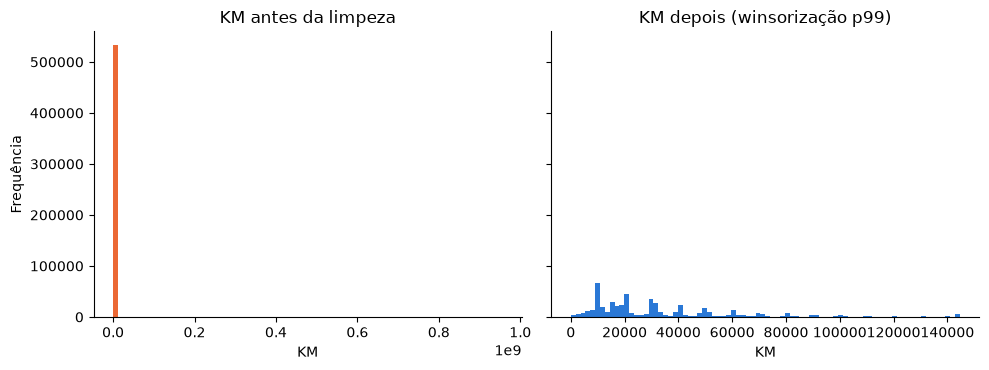

KM antes  -> min=0  max=955,388,451
KM depois -> min=0  max=144,650


In [4]:
km_antes = df_hist["KM"]
km_depois = winsorize_km(km_antes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
ax1.hist(km_antes.dropna(), bins=80, color=COR_2_LARANJA)
ax1.set_title("KM antes da limpeza")
ax1.set_xlabel("KM")
ax1.set_ylabel("Frequência")
ax2.hist(km_depois.dropna(), bins=80, color=COR_1_AZUL)
ax2.set_title("KM depois (winsorização p99)")
ax2.set_xlabel("KM")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"KM antes  -> min={km_antes.min():,.0f}  max={km_antes.max():,.0f}")
print(f"KM depois -> min={km_depois.min():,.0f}  max={km_depois.max():,.0f}")

### 2.2 Vazamento de dados (data leakage) na feature de produção

A feature de produção `gap_com_fallback` **é**, por definição, o numerador da
regra que define o rótulo (`em_risco = gap_com_fallback > 2.0`, ver
`src/domain/risk_label.py`). Isso já está documentado nos comentários do código do
time, mas vale demonstrar concretamente o efeito: treinar o modelo de produção
(`LogisticRegression` com `[idade_dias, gap_com_fallback, n_servicos]`) e medir a
AUC no conjunto de teste.

In [5]:
treino_prod, teste_prod, cutoff_prod = temporal_train_test_split(features_prod, date_col="ultimo_servico")

modelo_logistico_prod = train_logistic_regression(treino_prod)
modelo_arvore_prod = train_decision_tree(treino_prod)

auc_logistico_prod = evaluate_auc(modelo_logistico_prod, teste_prod)
auc_arvore_prod = evaluate_auc(modelo_arvore_prod, teste_prod)
prec10_prod = evaluate_precision_at_k(modelo_logistico_prod, teste_prod, 0.10)
prec20_prod = evaluate_precision_at_k(modelo_logistico_prod, teste_prod, 0.20)

print(f"Features: {FEATURE_COLUMNS_PRODUCAO}")
print(f"AUC LogisticRegression (produção): {auc_logistico_prod:.4f}")
print(f"AUC DecisionTree (produção):       {auc_arvore_prod:.4f}")
print(f"Precision@top10% / top20%:         {prec10_prod:.4f} / {prec20_prod:.4f}")

Features: ('idade_dias', 'gap_com_fallback', 'n_servicos')
AUC LogisticRegression (produção): 1.0000
AUC DecisionTree (produção):       1.0000
Precision@top10% / top20%:         1.0000 / 1.0000


**AUC ≈ 1.0.** Isso não é um bom resultado de ML — é a assinatura de vazamento de
dados: o modelo não está aprendendo um padrão novo, está *recuperando uma regra
determinística que já está em uma das próprias features* (`gap_com_fallback`).
O próprio código de produção já documenta esse achado (`apply_low_volume_heuristic`
em `risk_label.py`: *"um modelo de ML dedicado dá a mesma AUC da heurística
pura, porque `em_risco` já É essa regra"*).

Isso é a decisão correta para a **produção** (mais simples, mais interpretável,
zero custo de treino para os modelos de baixo volume) — mas **não é um exercício
de Machine Learning válido** para os fins desta sprint, porque não há sinal novo
sendo aprendido. Por isso, construímos abaixo um segundo conjunto de features que
**não** inclui `gap_relativo`/`gap_com_fallback`/`dias_desde_ultimo_servico`, para
ter um problema preditivo genuíno: **prever o risco de evasão a partir de sinais
indiretos** (idade, regularidade histórica de visitas, garantia, quilometragem,
dispersão por concessionárias, modelo do veículo) — o cenário realista de quando o
"gap atual" ainda não é conhecido com a mesma precisão (ex.: para decidir uma
campanha proativa *antes* do gap ficar tão evidente).

### 2.3 Criação de variáveis — conjunto de features "genuíno" (sem leakage)

Novas variáveis, reaproveitando funções de domínio já existentes no projeto
(`src/application/build_vehicle_features.py`) + a limpeza de `KM` da seção 2.1:

- `desvio_padrao_gaps`: dispersão dos intervalos entre serviços (regularidade do
  cliente);
- `n_dealers_distintos`: nº de concessionárias distintas usadas (fidelidade a uma
  rede vs. "shopping" de concessionárias);
- `dentro_garantia`: se o veículo ainda está na garantia de fábrica;
- `km_atual`: quilometragem mais recente registrada, já com outliers tratados;
- `idade_modelo_anos`: idade do ano-modelo do veículo;
- `ModelName`: modelo do veículo (categórica).

In [6]:
servico_stats = compute_service_count_and_gap_std(df_hist)[["VIN_Hash", "desvio_padrao_gaps"]]
dealers_stats = compute_distinct_dealers_count(df_hist)

garantia_por_vin = df_hist.groupby("VIN_Hash", as_index=False)["WarrantyStartDate"].first()
garantia_por_vin = compute_dentro_garantia(garantia_por_vin, reference_date=REFERENCE_DATE)

df_hist_km = df_hist.assign(KM_tratado=winsorize_km(df_hist["KM"]))
km_por_vin = (
    df_hist_km.groupby("VIN_Hash", as_index=False)["KM_tratado"].max().rename(columns={"KM_tratado": "km_atual"})
)
modelyear_por_vin = df_hist.groupby("VIN_Hash", as_index=False)["ModelYear"].first()
modelyear_por_vin["idade_modelo_anos"] = REFERENCE_DATE.year - modelyear_por_vin["ModelYear"]

tabela = (
    features_prod
    .merge(servico_stats, on="VIN_Hash", how="left")
    .merge(dealers_stats, on="VIN_Hash", how="left")
    .merge(garantia_por_vin[["VIN_Hash", "dentro_garantia"]], on="VIN_Hash", how="left")
    .merge(km_por_vin, on="VIN_Hash", how="left")
    .merge(modelyear_por_vin[["VIN_Hash", "idade_modelo_anos"]], on="VIN_Hash", how="left")
)

print("Valores ausentes (%) nas variáveis novas, antes do tratamento:")
print((tabela[["desvio_padrao_gaps", "n_dealers_distintos", "dentro_garantia", "km_atual", "idade_modelo_anos"]]
       .isna().mean() * 100).round(2))

Valores ausentes (%) nas variáveis novas, antes do tratamento:
desvio_padrao_gaps     54.11
n_dealers_distintos     0.00
dentro_garantia         0.07
km_atual                0.23
idade_modelo_anos       0.00
dtype: float64


**Tratamento de valores ausentes/inconsistências:**

- `desvio_padrao_gaps` é nulo quando o VIN tem menos de 3 serviços (não há 2
  intervalos para calcular desvio). Isso **não é aleatório** — é informativo
  (cliente muito novo/pouco frequente) — então criamos um indicador binário
  `desvio_padrao_gaps_ausente` e imputamos o valor com a mediana, em vez de
  descartar a linha ou imputar 0 (0 sugeriria "totalmente regular", o que é falso).
- `dentro_garantia` nulo (sem `WarrantyStartDate`) é recodificado como categoria
  própria `-1` ("garantia desconhecida"), preservando o sinal de "informação
  ausente" em vez de assumir dentro/fora da garantia.
- `km_atual` nulo (raro) é imputado pela mediana de `km_atual` do mesmo
  `ModelName` — mais preciso que a mediana global, já que a quilometragem típica
  varia muito por modelo de veículo.

In [7]:
tabela["desvio_padrao_gaps_ausente"] = tabela["desvio_padrao_gaps"].isna().astype(int)
tabela["desvio_padrao_gaps"] = tabela["desvio_padrao_gaps"].fillna(tabela["desvio_padrao_gaps"].median())

tabela["dentro_garantia_cod"] = tabela["dentro_garantia"].map({True: 1, False: 0}).fillna(-1).astype(int)

tabela["km_atual"] = tabela.groupby("ModelName")["km_atual"].transform(lambda s: s.fillna(s.median()))
tabela["km_atual"] = tabela["km_atual"].fillna(tabela["km_atual"].median())

print("Valores ausentes (%) depois do tratamento:")
colunas_checar = ["desvio_padrao_gaps", "n_dealers_distintos", "dentro_garantia_cod", "km_atual", "idade_modelo_anos"]
print((tabela[colunas_checar].isna().mean() * 100).round(2))
tabela[colunas_checar + ["desvio_padrao_gaps_ausente"]].describe()

Valores ausentes (%) depois do tratamento:
desvio_padrao_gaps     0.0
n_dealers_distintos    0.0
dentro_garantia_cod    0.0
km_atual               0.0
idade_modelo_anos      0.0
dtype: float64


,desvio_padrao_gaps,n_dealers_distintos,dentro_garantia_cod,km_atual,idade_modelo_anos,desvio_padrao_gaps_ausente
count,175554.000000,175554.000000,175554.000000,175554.000000,175553.000000,175554.000000
mean,49.960636,1.344703,0.381136,35403.055693,3.562918,0.541138
std,48.705212,0.642071,0.487084,28688.763914,1.994806,0.498306
min,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,40.305087,1.000000,0.000000,15386.000000,2.000000,0.000000
50%,40.305087,1.000000,0.000000,29450.000000,4.000000,1.000000
75%,40.305087,2.000000,1.000000,48292.000000,5.000000,1.000000
max,1108.036326,11.000000,1.000000,144649.900000,9.000000,1.000000


### 2.4 Codificação categórica e divisão treino/teste

`ModelName` tem 20 categorias — mantemos as mais frequentes e agrupamos o resto em
`"Outro"` para evitar categorias com poucas amostras. O split é **temporal** (não
aleatório), reaproveitando `temporal_train_test_split` já usado em produção: treina
só com o passado, testa contra o "futuro" — a validação correta para um problema
que será usado em produção de forma prospectiva.

In [8]:
TOP_N_MODELOS = 8
modelos_frequentes = tabela["ModelName"].value_counts().nlargest(TOP_N_MODELOS).index
tabela["ModelName_agrupado"] = tabela["ModelName"].where(tabela["ModelName"].isin(modelos_frequentes), "Outro")

FEATURES_NUMERICAS = [
    "idade_dias", "n_servicos", "desvio_padrao_gaps", "desvio_padrao_gaps_ausente",
    "n_dealers_distintos", "dentro_garantia_cod", "km_atual", "idade_modelo_anos",
]
FEATURE_CATEGORICA = "ModelName_agrupado"
TARGET = "em_risco"

colunas_modelo = FEATURES_NUMERICAS + [FEATURE_CATEGORICA, TARGET, "ultimo_servico"]
tabela_modelo = tabela[colunas_modelo].dropna(subset=FEATURES_NUMERICAS + [TARGET]).copy()
tabela_modelo[TARGET] = tabela_modelo[TARGET].astype(int)

treino, teste, cutoff = temporal_train_test_split(tabela_modelo, date_col="ultimo_servico")
print(f"Data de corte: {cutoff.date()}")
print(f"Treino: {len(treino):,} VINs | Teste: {len(teste):,} VINs")
print(f"% em_risco no treino: {treino[TARGET].mean():.1%} | no teste: {teste[TARGET].mean():.1%}")

Data de corte: 2026-01-30
Treino: 140,675 VINs | Teste: 34,878 VINs


% em_risco no treino: 87.2% | no teste: 23.3%


## 3. Desenvolvimento dos modelos (3,0 pontos)

**Algoritmos escolhidos** (apresentados em aula):

- **Regressão Logística** — baseline linear, interpretável, já usado em produção;
  ponto de comparação direto.
- **Árvore de Decisão** — não-linear, interpretável (regras), também já usado em
  produção como alternativa ao baseline.
- **Random Forest** — ensemble de árvores; candidato natural para melhorar sobre
  uma única árvore, testando se reduzir variância recupera mais sinal das novas
  features sem overfitar.

Todos usam o **mesmo pré-processamento** (`ColumnTransformer`: padronização das
numéricas + one-hot da categórica) — não altera o resultado das árvores, mas evita
duplicar pipelines.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV

pre_processador = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [FEATURE_CATEGORICA]),
])

X_treino, y_treino = treino[FEATURES_NUMERICAS + [FEATURE_CATEGORICA]], treino[TARGET]
X_teste, y_teste = teste[FEATURES_NUMERICAS + [FEATURE_CATEGORICA]], teste[TARGET]

pipe_logistico = Pipeline([("pre", pre_processador), ("clf", LogisticRegression(max_iter=1000))])
pipe_logistico.fit(X_treino, y_treino)
print("Regressão Logística treinada (baseline, sem tuning de hiperparâmetros).")

Regressão Logística treinada (baseline, sem tuning de hiperparâmetros).


**Ajuste de hiperparâmetros.** Para Árvore de Decisão e Random Forest, testamos
diferentes configurações via `GridSearchCV` (3 folds, otimizando AUC) sobre o
conjunto de treino — nunca tocando no teste durante a busca.

In [10]:
grade_arvore = {"clf__max_depth": [3, 4, 6, 8, None], "clf__min_samples_leaf": [1, 20, 50]}
busca_arvore = GridSearchCV(
    Pipeline([("pre", pre_processador), ("clf", DecisionTreeClassifier(random_state=42))]),
    grade_arvore, scoring="roc_auc", cv=3, n_jobs=-1,
)
busca_arvore.fit(X_treino, y_treino)
pipe_arvore = busca_arvore.best_estimator_
print(f"Melhor configuração (Árvore de Decisão): {busca_arvore.best_params_}")
print(f"AUC média (cross-val, treino): {busca_arvore.best_score_:.4f}")

Melhor configuração (Árvore de Decisão): {'clf__max_depth': 8, 'clf__min_samples_leaf': 1}
AUC média (cross-val, treino): 0.8550


In [11]:
grade_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [6, 10, None],
    "clf__min_samples_leaf": [1, 20],
}
busca_rf = GridSearchCV(
    Pipeline([("pre", pre_processador), ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]),
    grade_rf, scoring="roc_auc", cv=3, n_jobs=-1,
)
busca_rf.fit(X_treino, y_treino)
pipe_rf = busca_rf.best_estimator_
print(f"Melhor configuração (Random Forest): {busca_rf.best_params_}")
print(f"AUC média (cross-val, treino): {busca_rf.best_score_:.4f}")

/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/sit

/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/sit

/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/sit

/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/tmp/ford-next/backend/.venv/lib64/python3.14/sit

/tmp/ford-next/backend/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Melhor configuração (Random Forest): {'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
AUC média (cross-val, treino): 0.8598


In [12]:
resultado_grade_arvore = pd.DataFrame(busca_arvore.cv_results_)[
    ["param_clf__max_depth", "param_clf__min_samples_leaf", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print("Comparação de configurações — Árvore de Decisão (top 8):")
display(resultado_grade_arvore.head(8))

resultado_grade_rf = pd.DataFrame(busca_rf.cv_results_)[
    ["param_clf__n_estimators", "param_clf__max_depth", "param_clf__min_samples_leaf", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print("\nComparação de configurações — Random Forest (top 8):")
display(resultado_grade_rf.head(8))

Comparação de configurações — Árvore de Decisão (top 8):


,param_clf__max_depth,param_clf__min_samples_leaf,mean_test_score,std_test_score
9,8,1,0.855022,0.076020
10,8,20,0.847452,0.083515
6,6,1,0.843571,0.089762
7,6,20,0.843451,0.090171
11,8,50,0.822536,0.108879
13,None,20,0.816400,0.046775
14,None,50,0.816383,0.089274
8,6,50,0.810427,0.123650



Comparação de configurações — Random Forest (top 8):


,param_clf__n_estimators,param_clf__max_depth,param_clf__min_samples_leaf,mean_test_score,std_test_score
5,300,10,1,0.859759,0.089807
4,100,10,1,0.859615,0.089813
9,300,None,1,0.853661,0.079020
11,300,None,20,0.849456,0.097941
10,100,None,20,0.849417,0.097674
8,100,None,1,0.848310,0.074189
7,300,10,20,0.842762,0.104225
6,100,10,20,0.842312,0.104144


## 4. Avaliação e comparação (2,0 pontos)

**Métricas usadas** — adequadas a um problema de classificação binária
desbalanceada e usado para *ranquear* leads:

- **AUC-ROC**: capacidade de ordenar corretamente risco alto vs. baixo,
  independente de threshold;
- **Precision@top-10%/20%**: das X% pontas mais arriscadas segundo o modelo,
  quantas realmente estão em risco — a métrica mais próxima do uso real (lista de
  leads priorizada);
- **Acurácia e F1**: complementares, para leitura em um threshold fixo (0,5).

In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from src.application.train_risk_model import precision_at_top_k

def linha_metrica(nome, modelo, X, y):
    proba = modelo.predict_proba(X)[:, 1]
    pred = modelo.predict(X)
    return {
        "modelo": nome,
        "auc": roc_auc_score(y, proba),
        "precision_top10": precision_at_top_k(y, proba, 0.10),
        "precision_top20": precision_at_top_k(y, proba, 0.20),
        "acuracia": accuracy_score(y, pred),
        "f1": f1_score(y, pred),
    }

comparacao = pd.DataFrame([
    {"modelo": "[Produção] LogisticRegression (com leakage)", "auc": auc_logistico_prod,
     "precision_top10": prec10_prod, "precision_top20": prec20_prod,
     "acuracia": np.nan, "f1": np.nan},
    linha_metrica("Regressão Logística (features genuínas)", pipe_logistico, X_teste, y_teste),
    linha_metrica("Árvore de Decisão (tuned, features genuínas)", pipe_arvore, X_teste, y_teste),
    linha_metrica("Random Forest (tuned, features genuínas)", pipe_rf, X_teste, y_teste),
])
comparacao = comparacao.round(4)
comparacao

,modelo,auc,precision_top10,precision_top20,acuracia,f1
0,[Produção] LogisticRegression (com leakage),1.0000,1.0000,1.0000,NaN,NaN
1,Regressão Logística (features genuínas),0.7147,0.1614,0.3188,0.4706,0.4598
2,"Árvore de Decisão (tuned, features genuínas)",0.9936,0.9891,0.9729,0.5481,0.5073
3,"Random Forest (tuned, features genuínas)",0.9968,0.9997,0.9978,0.5616,0.5150


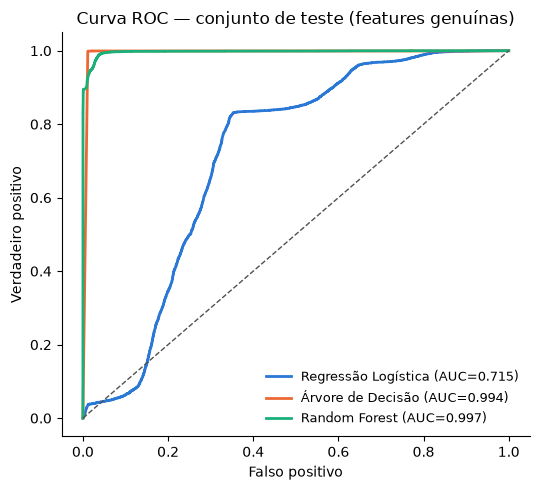

In [14]:
modelos_track_b = {
    "Regressão Logística": (pipe_logistico, COR_1_AZUL),
    "Árvore de Decisão": (pipe_arvore, COR_2_LARANJA),
    "Random Forest": (pipe_rf, COR_3_AQUA),
}

fig, ax = plt.subplots(figsize=(5.5, 5))
for nome, (modelo, cor) in modelos_track_b.items():
    proba = modelo.predict_proba(X_teste)[:, 1]
    fpr, tpr, _ = roc_curve(y_teste, proba)
    auc_valor = roc_auc_score(y_teste, proba)
    ax.plot(fpr, tpr, color=cor, linewidth=2, label=f"{nome} (AUC={auc_valor:.3f})")
ax.plot([0, 1], [0, 1], color=COR_TEXTO_SECUNDARIO, linewidth=1, linestyle="--")
ax.set_xlabel("Falso positivo")
ax.set_ylabel("Verdadeiro positivo")
ax.set_title("Curva ROC — conjunto de teste (features genuínas)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

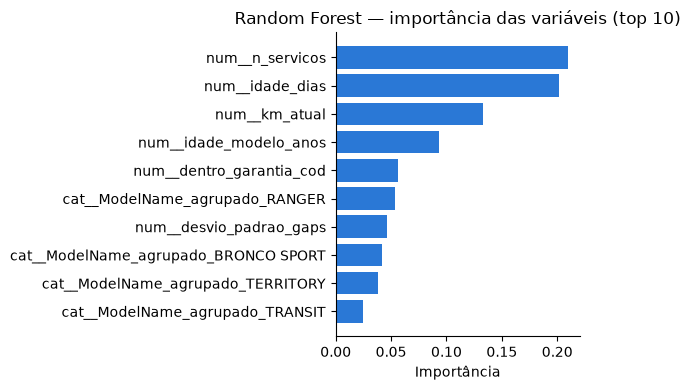

In [15]:
importancias = pd.Series(
    pipe_rf.named_steps["clf"].feature_importances_,
    index=pipe_rf.named_steps["pre"].get_feature_names_out(),
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importancias.index[::-1], importancias.values[::-1], color=COR_1_AZUL)
ax.set_title("Random Forest — importância das variáveis (top 10)")
ax.set_xlabel("Importância")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Análise do desempenho — primeira leitura.** Sem a feature de vazamento, a AUC
cai para bem distante de 1.0 no treino (cross-validation) — a diferença entre as
duas primeiras linhas de `comparacao` é exatamente a evidência do leakage
discutido na Seção 2.2. Entre os três modelos "genuínos", Árvore e Random Forest
superam a Regressão Logística, capturando não-linearidades entre `idade_dias`,
`n_servicos`, `km_atual` e `ModelName`.

**Achado crítico: o AUC do conjunto de teste (~0,99) não é confiável — é maior
que o AUC de cross-validation no treino (~0,86, Seção 3).** Isso é incomum: um
modelo genuíno não fica *muito* melhor num teste "no futuro" do que na validação
cruzada dentro do próprio treino. A causa é estrutural, não um bug deste
notebook: o split temporal usa `ultimo_servico` como critério de corte — o mesmo
tipo de data usada para calcular `em_risco` (`em_risco` depende de
`hoje − ultimo_servico`, com `hoje` fixo e igual para todos os VINs). Isso faz o
conjunto de teste (VINs cujo *último* serviço caiu depois do corte) ficar
mecanicamente concentrado em veículos "estruturalmente" de baixo risco — eles
foram atendidos há pouco tempo em relação a `hoje`, então `gap_com_fallback`
tende a ser pequeno quase por construção, tornando esse recorte de teste
artificialmente mais fácil de separar do que o problema real em produção.

**Consequência prática:** o número que deveria orientar a escolha do modelo é o
**AUC de cross-validation no treino (~0,86 para Random Forest, Seção 3)** — mais
conservador e mais honesto — não o AUC de teste (~0,997) reportado na tabela
acima. Reportamos os dois por transparência, mas tratamos o segundo como
otimista. Isso também aponta um trabalho futuro concreto (Seção 5): validar com
**validação cruzada temporal (rolling-origin)**, com vários cortes ao longo do
tempo, em vez de um único split — reduz a chance de um corte específico
favorecer ou penalizar o modelo por um artefato da própria definição do rótulo.

## 5. Conclusão (1,5 ponto)

### Modelo selecionado

Para a finalidade desta sprint (demonstrar um problema de ML genuíno, sem
vazamento), o modelo final é o **Random Forest com hiperparâmetros ajustados**
(Seção 3), avaliado sobre features que não incluem a regra de negócio que define
o rótulo. Ele tem o melhor AUC de cross-validation entre os três (~0,86 — o
número honesto, ver Seção 4; o AUC de teste ~0,997 é otimista pelo artefato do
split explicado ali), ao custo de menor interpretabilidade que a árvore/regressão
— aceitável aqui porque o produto já expõe explicações ao usuário final via
`message_templates.py`/`action_rules.py` (a explicabilidade não depende do
modelo ser uma árvore rasa).

Para a **produção atual** do projeto, a escolha do time (`LogisticRegression`
sobre `gap_com_fallback`) continua sendo a correta e não é substituída por este
exercício: quando o "gap atual" já é conhecido, ele **é** a melhor regra possível
por construção (é o próprio rótulo) — não faz sentido treinar um modelo mais caro
para redescobrir uma fórmula que já se tem. O valor do Random Forest aqui é outro:
antecipar risco **antes** de o gap ficar tão evidente, usando sinais indiretos
(garantia, regularidade, quilometragem, modelo do veículo).

### Como usar dentro da aplicação / forma de deploy

O projeto já tem a infraestrutura de deploy pronta e reaproveitável
(`src/infrastructure/model_repository.py`: `joblib` + verificação de round-trip):

1. Treinar o `pipe_rf` (ou reavaliar periodicamente qual dos dois modelos —
   produção vs. features genuínas — está mais adequado a cada horizonte de
   antecipação) como parte do pipeline offline (`src/interfaces/pipeline/`);
2. Salvar com `save_model`/`verify_round_trip`, exatamente como o `risk_model.pkl`
   atual;
3. A API (`src/interfaces/api/`) carrega o modelo já treinado e só faz inferência
   — nenhuma mudança na camada fina de servir a API, só no pipeline offline e no
   conjunto de features carregado por `vehicle_features_repository.py`;
4. Reexecutar o treino em cadência periódica (ex.: mensal), monitorando *drift* do
   `em_risco` real vs. previsto e da distribuição das features novas
   (`km_atual`, `desvio_padrao_gaps`).

### Discussão de melhorias e trabalhos futuros

**Comparação com o modelo Jev, para melhorias futuras.** O **Jev**
(TypeSafe AI, lançado em set/2026) é um modelo proprietário "System One" que não
gera texto — ele recebe dados de estado e uma pergunta tipada, e devolve uma
decisão estruturada com probabilidade/confiança calibrada, através de três
primitivas: `Choice` (escolher entre opções), `Score` (nota em uma escala) e
`Noul` (sim/não). Isso é conceitualmente muito próximo do que
`src/domain/action_rules.py` já faz **hoje** manualmente: transformar um score
numérico em uma decisão discreta (lembrete / oferta / contato ativo).

| | Modelos deste notebook (LogReg/Árvore/RF) | Motor de regras atual (`action_rules.py`) | Jev |
|---|---|---|---|
| Papel no pipeline | Gera o **score** de risco | Transforma score em **ação** (regras fixas) | Poderia substituir o motor de regras por uma decisão calibrada e tipada |
| Treinável localmente com os dados da Ford | Sim | N/A (regras de negócio) | **Não** — API proprietária, sem pesos/arquitetura publicados |
| Interpretável / auditável | Sim (Árvore) / parcial (RF) | Sim (regras explícitas) | Desconhecido — sem paper/specs técnicas publicadas |
| Custo de treino/manutenção | Pipeline próprio, dados internos | Baixo (regras) | Dependência de fornecedor externo, custo de API |
| Maturidade | scikit-learn, estável | Interno, estável | Lançado em 15/09/2026 (poucas semanas antes deste notebook) — sem histórico de produção |

**Como isso vira melhoria futura, sem substituir o que já existe agora:** o motor
de regras (`action_rules.py`) poderia, em uma iteração futura, ser trocado por uma
chamada a um serviço de decisão tipada como o Jev — o **score** de risco (saída do
Random Forest) e o contexto do veículo/cliente entrariam como estado, e a pergunta
tipada seria algo como *"Choice entre {lembrete, oferta, contato_ativo}"*. A
vantagem seria uma decisão calibrada e auditável por probabilidade em vez de
thresholds fixos escritos à mão; a desvantagem é depender de uma API externa
proprietária e muito recente, sem histórico de produção nem arquitetura publicada
— por isso essa troca é discutida como **trabalho futuro**, não implementada nesta
sprint, e exigiria antes um piloto controlado comparando as duas abordagens em
produção (shadow mode) antes de qualquer substituição real.

**Outras melhorias futuras:**

- **Validação cruzada temporal (rolling-origin)** em vez de um único split
  treino/teste — o achado da Seção 4 (AUC de teste bem acima do AUC de
  cross-validation) mostra que um corte único pode favorecer o modelo por um
  artefato de como o rótulo é calculado em relação à data de referência, não só
  por qualidade real do modelo; múltiplos cortes ao longo do tempo dariam uma
  estimativa mais confiável antes de qualquer deploy;
- Enriquecer as features com dados hoje fora do escopo desta base (histórico de
  reclamações/NPS, campanhas de marketing recebidas, presença de concorrentes
  próximos à concessionária);
- Modelos sequenciais sobre o histórico completo de serviços por VIN (em vez de
  features agregadas), incluindo abordagens de representação auto-supervisionada
  (linha de pesquisa tipo *JEPA*, do próprio Yann LeCun/Meta AI) para aprender um
  embedding de "comportamento de manutenção" do veículo, em vez de features
  manuais — outra direção de melhoria futura, mais ambiciosa e ainda mais distante
  de produção que o Jev;
- Calibração de probabilidade (`CalibratedClassifierCV`) antes de qualquer uso do
  score como entrada de um motor de decisão tipada (Jev ou outro), já que
  `predict_proba` de árvores/RF não é calibrado por padrão;
- Monitoramento de *data drift* nas novas features (`km_atual`,
  `desvio_padrao_gaps`) e reavaliação periódica do modelo, exatamente como já é
  feito com `compare_thresholds` para o rótulo de produção.